# Alerta 2 (Transmisión / Malinversión): preparación de features

Este notebook se limita a la **Fase 2** del proyecto: construcción de variables para capturar la transmisión de la distorsión monetaria hacia la estructura productiva y los precios de activos.

Criterios fijados para esta fase:
- Ventana temporal común: **1980-01-01 a 2025-10-01**.
- Series base: `IPBUSEQ`, `PCE`, `NASDAQCOM`, `Price` (oro) y `USSTHPI`.
- Homologación de frecuencia:
  - `NASDAQCOM`: promedio mensual.
  - `USSTHPI`: interpolación lineal mensual.
  - Resto: mensual tal cual.
- Features autorizados:
  - Ratios.
  - Media móvil de 6 meses (`MA6`) de los ratios.
  - Variación interanual (`YoY%`) de los ratios.
  - Rolling z-score de 24 meses.
- Etiqueta objetivo: misma `Y` híbrida del Notebook 1 con horizonte de 18 meses.
- Salida final: exportación de `dataset_alerta2.csv`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

sns.set_theme(style='whitegrid')

START_DATE = '1980-01-01'
END_DATE = '2025-10-01'
TARGET_SHIFT_MONTHS = 18
Z_SCORE_WINDOW = 24
MA_WINDOW = 6

DATA_DIR = Path('datos ABCT')
OUTPUT_PATH = Path('dataset_alerta2.csv')

NBER_PERIODS = [
    ('1980-01-01', '1980-07-01'),
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01'),
]

In [2]:
def load_monthly_series(csv_path: Path, value_col: str, date_col: str = 'observation_date') -> pd.Series:
    df = pd.read_csv(csv_path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df[[date_col, value_col]].dropna()
    df = df.rename(columns={date_col: 'date', value_col: value_col.lower()})
    df = df.set_index('date').sort_index()
    df.index = df.index.to_period('M').to_timestamp(how='start')
    return df[value_col.lower()]


def load_nasdaq_monthly_average(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    df = df[['observation_date', 'NASDAQCOM']].dropna()
    df['month'] = df['observation_date'].dt.to_period('M').dt.to_timestamp(how='start')
    monthly_avg = df.groupby('month', as_index=True)['NASDAQCOM'].mean().sort_index()
    monthly_avg.name = 'nasdaqcom'
    return monthly_avg


def load_gold_monthly_series(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')
    df = df[['Date', 'Price']].dropna()
    df = df.rename(columns={'Date': 'date', 'Price': 'price'})
    df = df.set_index('date').sort_index()
    df.index = df.index.to_period('M').to_timestamp(how='start')
    return df['price']


def monthly_interpolate_from_quarterly(series_q: pd.Series, start: str, end: str) -> pd.Series:
    monthly_idx = pd.date_range(start=start, end=end, freq='MS')
    return series_q.reindex(monthly_idx).interpolate(method='linear')


def rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    rolling_mean = series.rolling(window=window, min_periods=window).mean()
    rolling_std = series.rolling(window=window, min_periods=window).std()
    return (series - rolling_mean) / rolling_std.replace(0, np.nan)

In [3]:
monthly_index = pd.date_range(start=START_DATE, end=END_DATE, freq='MS')

ipbuseq = load_monthly_series(DATA_DIR / 'IPBUSEQ - mensual - hasta 2026.csv', 'IPBUSEQ')
pce = load_monthly_series(DATA_DIR / 'PCE - mensual - hasta 2026.csv', 'PCE')
nasdaqcom = load_nasdaq_monthly_average(DATA_DIR / 'NASDAQCOM - 1980 a 2026.csv')
gold_price = load_gold_monthly_series(DATA_DIR / 'Onza de oro - mensual - no ajustado por inflacion.csv')
ussthpi_q = load_monthly_series(DATA_DIR / 'USSTHPI - trimestral - hasta 01oct25.csv', 'USSTHPI')
gdpc1_q = load_monthly_series(DATA_DIR / 'GDPC1 - trimestral - hasta 01oct2025.csv', 'GDPC1')

base = pd.DataFrame(index=monthly_index)
base['ipbuseq'] = ipbuseq.reindex(monthly_index)
base['pce'] = pce.reindex(monthly_index)
base['nasdaqcom'] = nasdaqcom.reindex(monthly_index)
base['gold_price'] = gold_price.reindex(monthly_index)
base['ussthpi'] = monthly_interpolate_from_quarterly(ussthpi_q, START_DATE, END_DATE)
base['gdpc1'] = monthly_interpolate_from_quarterly(gdpc1_q, START_DATE, END_DATE)

print('Rango final:', base.index.min().date(), '->', base.index.max().date())
print('Filas:', len(base))
base[['ipbuseq', 'pce', 'nasdaqcom', 'gold_price', 'ussthpi']].head()

Rango final: 1980-01-01 -> 2025-10-01
Filas: 550


,ipbuseq,pce,nasdaqcom,gold_price,ussthpi
1980-01-01,30.5763,1697.3,155.140909,675.31,100.000000
1980-02-01,30.7250,1701.4,161.644000,665.32,100.556667
1980-03-01,30.4631,1708.2,141.100476,553.58,101.113333
1980-04-01,30.1642,1695.2,136.286667,517.41,101.670000
1980-05-01,29.6816,1700.1,145.684762,513.80,102.590000


In [4]:
# Etiqueta objetivo consistente con el Notebook 1
base['gdpc1_yoy_pct'] = base['gdpc1'].pct_change(12) * 100
base['crisis_gdpc1'] = (base['gdpc1_yoy_pct'] <= 0).astype(int)

base['crisis_nber'] = 0
for start, end in NBER_PERIODS:
    mask = (base.index >= pd.Timestamp(start)) & (base.index <= pd.Timestamp(end))
    base.loc[mask, 'crisis_nber'] = 1

base['crisis_now'] = ((base['crisis_nber'] == 1) | (base['crisis_gdpc1'] == 1)).astype(int)
base['y_crisis_t_plus_18m'] = base['crisis_now'].shift(-TARGET_SHIFT_MONTHS)

# Ratios principales autorizados
base['ipbuseq_pce_ratio'] = base['ipbuseq'] / base['pce']
base['nasdaq_gold_ratio'] = base['nasdaqcom'] / base['gold_price']
base['ussthpi_gold_ratio'] = base['ussthpi'] / base['gold_price']

ratio_columns = ['ipbuseq_pce_ratio', 'nasdaq_gold_ratio', 'ussthpi_gold_ratio']

for col in ratio_columns:
    base[f'{col}_ma6'] = base[col].rolling(window=MA_WINDOW, min_periods=MA_WINDOW).mean()
    base[f'{col}_yoy_pct'] = base[col].pct_change(12) * 100
    base[f'{col}_zscore24'] = rolling_zscore(base[col], window=Z_SCORE_WINDOW)

feature_columns = []
for col in ratio_columns:
    feature_columns.extend([
        col,
        f'{col}_ma6',
        f'{col}_yoy_pct',
        f'{col}_zscore24',
    ])

model_df_2 = base[feature_columns + ['y_crisis_t_plus_18m']].copy()
model_df_2 = model_df_2.dropna()
model_df_2['y_crisis_t_plus_18m'] = model_df_2['y_crisis_t_plus_18m'].astype(int)

model_df_2.to_csv(OUTPUT_PATH, index=True, index_label='date')

print('Features finales:', len(feature_columns))
print('Observaciones útiles:', len(model_df_2))
print('Archivo exportado:', OUTPUT_PATH.resolve())
model_df_2.head()

Features finales: 12
Observaciones útiles: 509
Archivo exportado: D:\Python Projects\crisis\dataset_alerta2.csv


,ipbuseq_pce_ratio,ipbuseq_pce_ratio_ma6,ipbuseq_pce_ratio_yoy_pct,ipbuseq_pce_ratio_zscore24,nasdaq_gold_ratio,nasdaq_gold_ratio_ma6,nasdaq_gold_ratio_yoy_pct,nasdaq_gold_ratio_zscore24,ussthpi_gold_ratio,ussthpi_gold_ratio_ma6,ussthpi_gold_ratio_yoy_pct,ussthpi_gold_ratio_zscore24,y_crisis_t_plus_18m
1981-12-01,0.015144,0.015696,-9.543730,-1.877318,0.480747,0.471898,30.427757,1.247242,0.259943,0.256390,33.376969,1.440095,0
1982-01-01,0.014477,0.015432,-12.721529,-2.368025,0.488568,0.467879,36.971211,1.228986,0.276306,0.258084,46.578405,1.684683,0
1982-02-01,0.014823,0.015265,-8.858631,-1.810155,0.488142,0.465275,25.199392,1.133056,0.285899,0.261678,35.013990,1.740775,0
1982-03-01,0.014634,0.015062,-10.001513,-1.862939,0.524705,0.483102,28.631834,1.404382,0.326379,0.275522,52.837241,2.285777,0
1982-04-01,0.014387,0.014826,-12.433927,-1.970051,0.519110,0.497206,19.642438,1.242922,0.310049,0.286261,43.210417,1.715194,0


In [5]:
feature_summary = model_df_2.describe().T
feature_summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

pd.Series(feature_columns, name='feature_name')

0               ipbuseq_pce_ratio
1           ipbuseq_pce_ratio_ma6
2       ipbuseq_pce_ratio_yoy_pct
3      ipbuseq_pce_ratio_zscore24
4               nasdaq_gold_ratio
5           nasdaq_gold_ratio_ma6
6       nasdaq_gold_ratio_yoy_pct
7      nasdaq_gold_ratio_zscore24
8              ussthpi_gold_ratio
9          ussthpi_gold_ratio_ma6
10     ussthpi_gold_ratio_yoy_pct
11    ussthpi_gold_ratio_zscore24
Name: feature_name, dtype: str

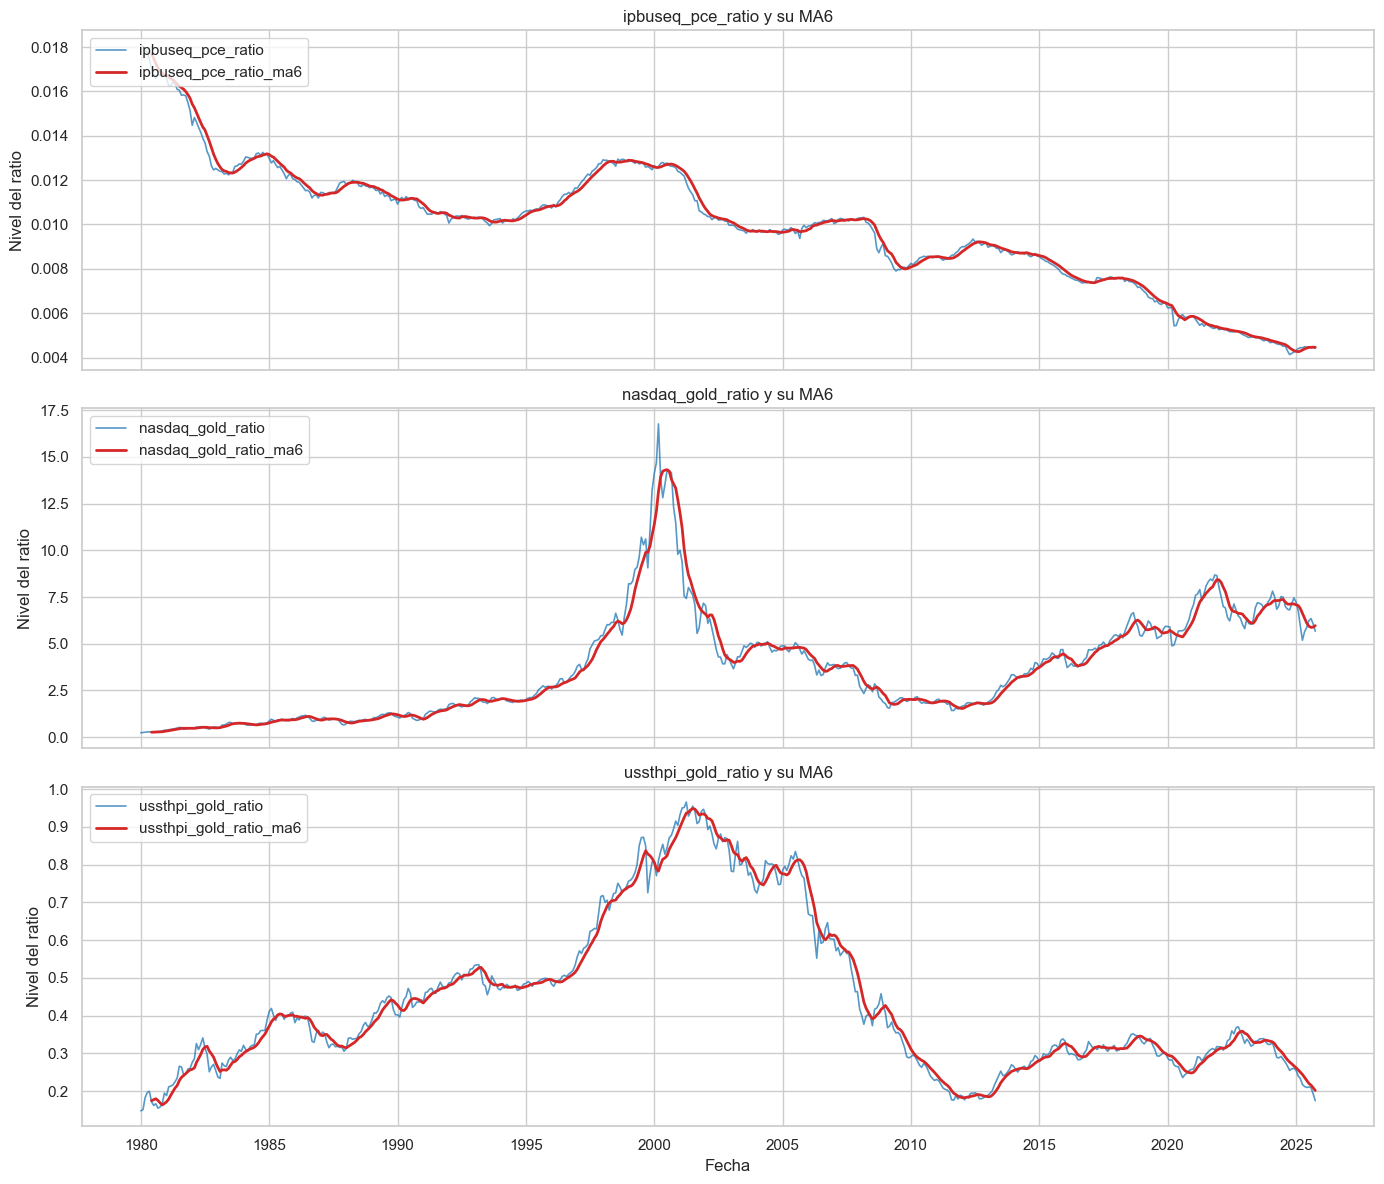

In [6]:
plot_feature_pairs = [
    ('ipbuseq_pce_ratio', 'ipbuseq_pce_ratio_ma6'),
    ('nasdaq_gold_ratio', 'nasdaq_gold_ratio_ma6'),
    ('ussthpi_gold_ratio', 'ussthpi_gold_ratio_ma6'),
]

fig, axes = plt.subplots(len(plot_feature_pairs), 1, figsize=(14, 12), sharex=True)

for ax, (ratio_col, ma_col) in zip(axes, plot_feature_pairs):
    ax.plot(base.index, base[ratio_col], label=ratio_col, linewidth=1.2, color='#1f77b4', alpha=0.75)
    ax.plot(base.index, base[ma_col], label=ma_col, linewidth=2.0, color='#d62728')
    ax.set_title(f'{ratio_col} y su MA6')
    ax.set_ylabel('Nivel del ratio')
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

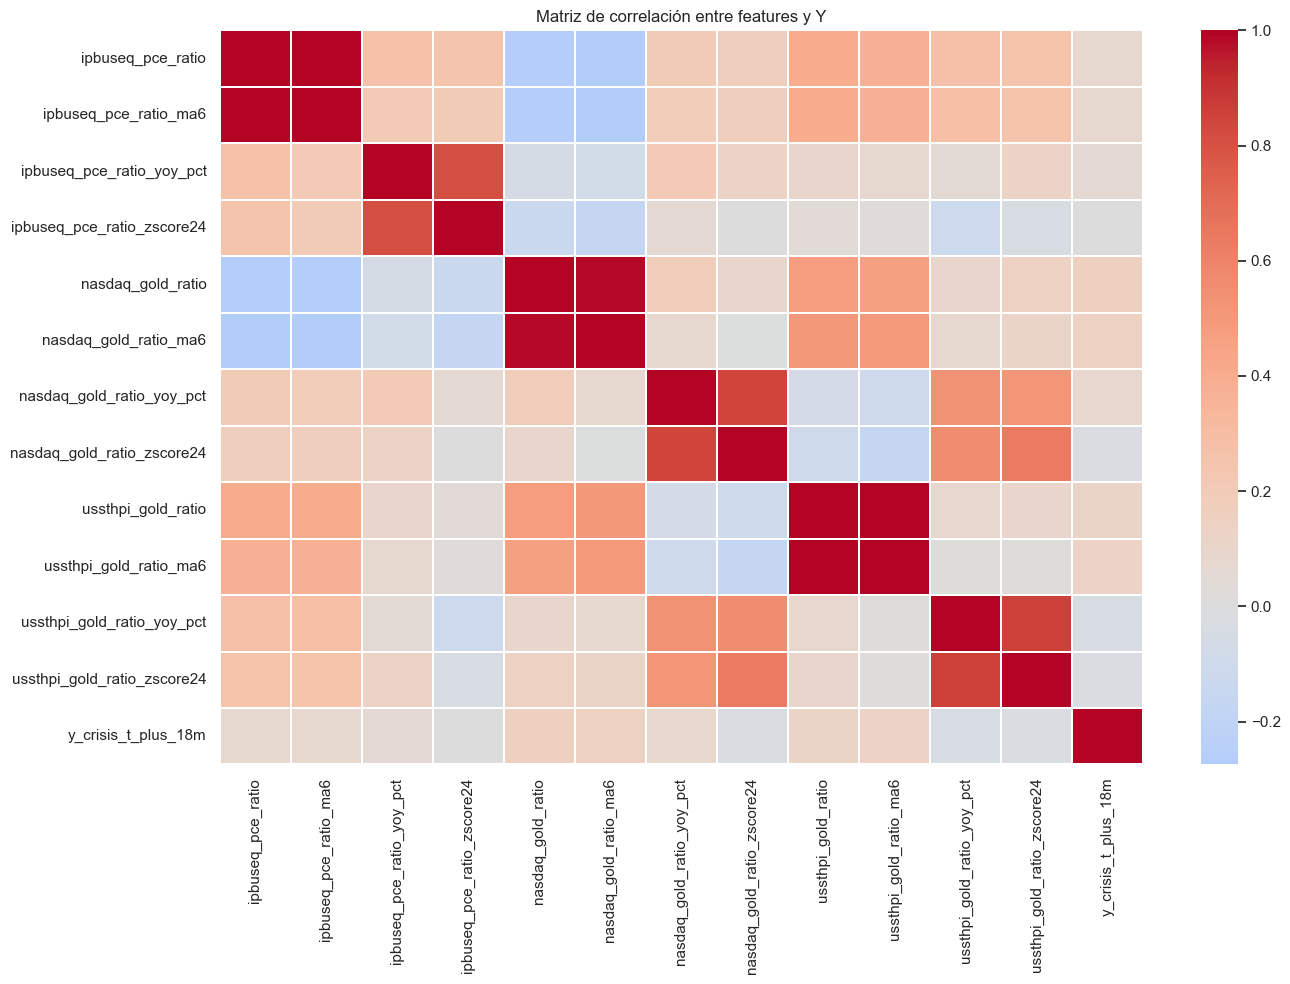

y_crisis_t_plus_18m            1.000000
nasdaq_gold_ratio              0.152377
nasdaq_gold_ratio_ma6          0.138740
ussthpi_gold_ratio_ma6         0.126259
ussthpi_gold_ratio             0.111274
nasdaq_gold_ratio_yoy_pct      0.088643
ipbuseq_pce_ratio              0.070121
ipbuseq_pce_ratio_ma6          0.069631
ipbuseq_pce_ratio_yoy_pct      0.059373
ipbuseq_pce_ratio_zscore24     0.008526
ussthpi_gold_ratio_zscore24   -0.026111
nasdaq_gold_ratio_zscore24    -0.030078
ussthpi_gold_ratio_yoy_pct    -0.044355
Name: y_crisis_t_plus_18m, dtype: float64

In [7]:
corr_matrix = model_df_2[feature_columns + ['y_crisis_t_plus_18m']].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Matriz de correlación entre features y Y')
plt.tight_layout()
plt.show()

corr_with_target = corr_matrix['y_crisis_t_plus_18m'].sort_values(ascending=False)
corr_with_target

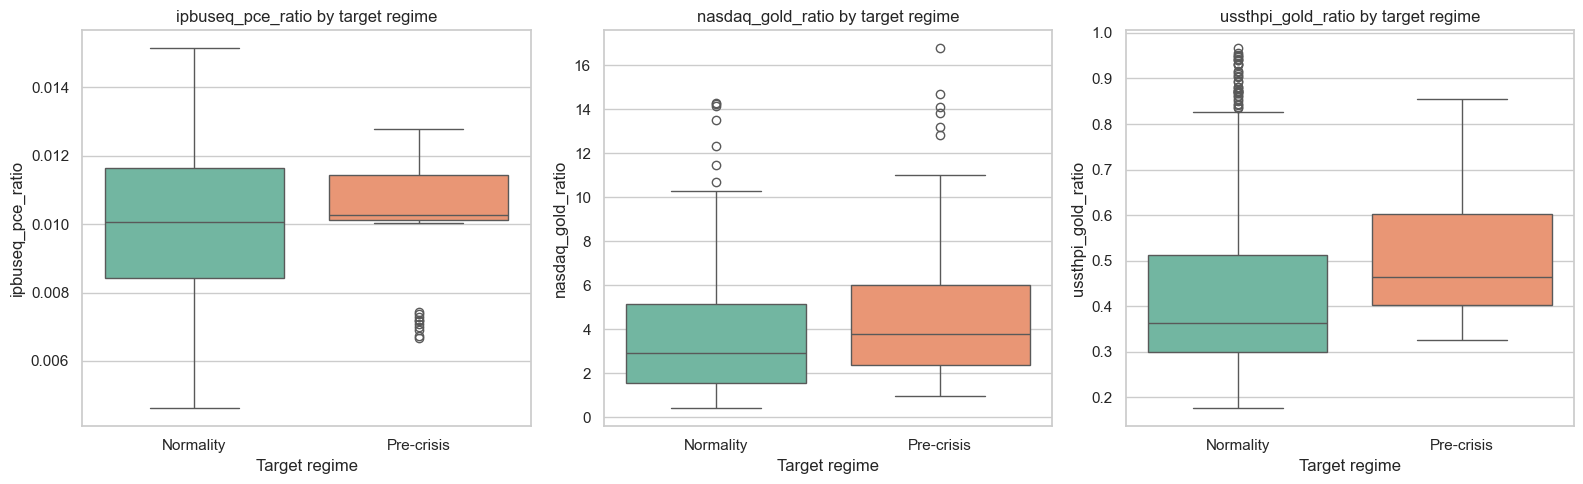

In [9]:
boxplot_df = model_df_2[['ipbuseq_pce_ratio', 'nasdaq_gold_ratio', 'ussthpi_gold_ratio', 'y_crisis_t_plus_18m']].copy()
boxplot_df['target_label'] = boxplot_df['y_crisis_t_plus_18m'].map({0: 'Normality', 1: 'Pre-crisis'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ratio_columns = ['ipbuseq_pce_ratio', 'nasdaq_gold_ratio', 'ussthpi_gold_ratio']
palette = {'Normality': '#66c2a5', 'Pre-crisis': '#fc8d62'}

for ax, col in zip(axes, ratio_columns):
    sns.boxplot(
        data=boxplot_df,
        x='target_label',
        y=col,
        hue='target_label',
        ax=ax,
        palette=palette,
        dodge=False,
        legend=False,
    )
    ax.set_title(f'{col} by target regime')
    ax.set_xlabel('Target regime')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()